# Anomaly Detection in ZTF Astronomical Transients
*AppliedML2026 – Final Project*

**Konstantinos Plainos**   |   University of Copenhagen, June 2026

---

The Zwicky Transient Facility (ZTF) observes millions of transient events per year.
Most are well-understood (supernovae, AGN, variable stars). This notebook builds an
**unsupervised autoencoder anomaly detector** to surface the unusual ones —
tidal disruption events, superluminous supernovae, and host-less transients.

**Pipeline:**
1. Load & clean data → drop artifact classes
2. Automatic feature selection via Pearson correlation filter
3. Winsorise + impute + z-score scale
4. Autoencoder trained on "normal" objects only (SN + AGN + VS), 5-fold CV
5. Score every object by out-of-fold reconstruction error
6. Validate against spectroscopic TNS labels; inspect top anomaly lightcurves

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os as _os

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold

import umap

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__}  |  device: {DEVICE}")

I0000 00:00:1780932779.949271  212401 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


PyTorch 2.6.0+cu124  |  device: cuda


## 1. Data Loading & Preprocessing

We load the ZTF photometric summary table, drop artifact / uncertain classes,
then select features automatically via a Pearson correlation filter.

**Classes kept:**
- **SN** (10,636) — supernovae: our dominant "normal" class
- **AGN** (1,532) — active galactic nuclei: another "normal" class
- **VS** (1,486) — variable stars: another "normal" class
- **NT** (1,781) — nuclear transients: evaluation only (not in AE training)
- **ORPHAN** (520) — host-less transients: evaluation only; expected to be anomalous

**Dropped:** BS (bright-star artefacts), CV (only 66 objects), UNCLEAR (uncertain labels)

In [2]:
df = pd.read_csv("data.csv", index_col=0)
print(f"Loaded: {df.shape[0]:,} objects × {df.shape[1]} columns")

DROP_CLASSES   = ["BS", "CV", "UNCLEAR"]
NORMAL_CLASSES = ["SN", "AGN", "VS"]
RARE_CLASSES   = ["NT", "ORPHAN"]

df_clean = df[~df["classification"].isin(DROP_CLASSES)].copy()
print(f"After dropping {DROP_CLASSES}: {len(df_clean):,} objects")
print()
print(df_clean["classification"].value_counts())

Loaded: 16,338 objects × 51 columns
After dropping ['BS', 'CV', 'UNCLEAR']: 15,955 objects

classification
SN        10636
NT         1781
AGN        1532
VS         1486
ORPHAN      520
Name: count, dtype: int64


## 2. Feature Selection & Scaling

Rather than hand-picking features we use a **data-driven approach**:

1. Start from all numeric columns, excluding labels, IDs, timestamps, and sky coordinates.
2. Winsorise and median-impute the full candidate set.
3. Drop one column from every pair with |Pearson r| > 0.90 — redundant features
   add noise but no information.
4. Apply final winsorise → impute → `StandardScaler` on the retained columns.

In [3]:
# Columns that are metadata/labels — excluded before correlation filter
EXCLUDE_META = [
    "classification", "classificationReliability", "tns_type", "tns_name",
    "host_name", "objectId", "htm16", "ssnamenr",
    "jdgmax", "jdrmax", "jdmax", "jdmin", "jd_g_minus_r",
    "ramean", "decmean", "glatmean", "glonmean",
]
CANDIDATE_COLS = [c for c in df_clean.columns if c not in EXCLUDE_META]
print(f"Candidate features: {len(CANDIDATE_COLS)}")

# Winsorise + impute candidates
X_cand = df_clean[CANDIDATE_COLS].copy()
lo_c, hi_c = X_cand.quantile(0.01), X_cand.quantile(0.99)
X_cand = X_cand.clip(lower=lo_c, upper=hi_c, axis=1)
imp_sel = SimpleImputer(strategy="median")
X_cand_imp = pd.DataFrame(imp_sel.fit_transform(X_cand), columns=CANDIDATE_COLS)

# Correlation filter
CORR_THRESHOLD = 0.90
upper = X_cand_imp.corr().abs()
upper = upper.where(np.triu(np.ones(upper.shape), k=1).astype(bool))
drop_corr    = {c for c in upper.columns if (upper[c] > CORR_THRESHOLD).any()}
FEATURE_COLS = [c for c in CANDIDATE_COLS if c not in drop_corr]

print(f"Dropped (|r| > {CORR_THRESHOLD}): {sorted(drop_corr)}")
print(f"Retained {len(FEATURE_COLS)} features")

Candidate features: 34


Dropped (|r| > 0.9): ['maggmin', 'magrmin']
Retained 32 features


In [4]:
# Final winsorise → impute → scale on retained features
X_raw = df_clean[FEATURE_COLS].copy()
lo, hi = X_raw.quantile(0.01), X_raw.quantile(0.99)
X_raw  = X_raw.clip(lower=lo, upper=hi, axis=1)

imputer  = SimpleImputer(strategy="median")
X_imp    = imputer.fit_transform(X_raw)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

labels      = df_clean["classification"].values
mask_normal = np.isin(labels, NORMAL_CLASSES)
X_normal    = X_scaled[mask_normal]

print(f"Feature matrix : {X_scaled.shape}")
print(f"Normal objects : {X_normal.shape[0]:,}  (AE training pool)")

Feature matrix : (15955, 32)
Normal objects : 13,654  (AE training pool)


## 3. Autoencoder Anomaly Detection

**Idea:** train an autoencoder exclusively on *normal* objects (SN + AGN + VS).
A network that learns to reconstruct typical ZTF transients will produce a high
**reconstruction error** on objects unlike anything it was trained on — that error
is our anomaly score.

Architecture (selected by hyperparameter sweep over 13 configurations):
```
Encoder: d → 1024 → 512 → 256 → 128 → 8   (latent)
Decoder: 8 → 128  → 256 → 512 → 1024 → d
Loss: MSE  |  Optimiser: Adam lr=1e-3  |  Epochs: 200 per fold
```

**5-fold cross-validation on normal objects:**
Each fold trains on 80% and scores the held-out 20% — giving every normal object
an **out-of-fold (OOF) score** from a model that never saw it.
NT and ORPHAN objects are never in any training fold; they are scored by all 5
models and averaged.

In [5]:
INPUT_DIM   = X_normal.shape[1]
HIDDEN_DIMS = [1024, 512, 256, 128]
LATENT_DIM  = 8


class Encoder(nn.Module):
    def __init__(self, input_dim, hidden, latent_dim):
        super().__init__()
        dims = [input_dim] + hidden
        layers = []
        for a, b in zip(dims[:-1], dims[1:]):
            layers += [nn.Linear(a, b), nn.ReLU()]
        layers.append(nn.Linear(dims[-1], latent_dim))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)


class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden, output_dim):
        super().__init__()
        rdims = list(reversed(hidden))
        layers = [nn.Linear(latent_dim, rdims[0]), nn.ReLU()]
        for a, b in zip(rdims[:-1], rdims[1:]):
            layers += [nn.Linear(a, b), nn.ReLU()]
        layers.append(nn.Linear(rdims[-1], output_dim))
        self.net = nn.Sequential(*layers)
    def forward(self, z): return self.net(z)


class AutoEncoder(nn.Module):
    def __init__(self, input_dim, hidden, latent_dim):
        super().__init__()
        self.encoder = Encoder(input_dim, hidden, latent_dim)
        self.decoder = Decoder(latent_dim, hidden, input_dim)
    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z


n_params = sum(p.numel() for p in AutoEncoder(INPUT_DIM, HIDDEN_DIMS, LATENT_DIM).parameters())
print(f"Input dim      : {INPUT_DIM}")
print(f"Trainable params: {n_params:,}")
print(f"Device         : {DEVICE}")

Input dim      : 32
Trainable params: 1,447,720
Device         : cuda


In [6]:
# ── 5-fold CV training ────────────────────────────────────────────────────────
EPOCHS     = 200
BATCH_SIZE = 256
LR         = 1e-3
N_FOLDS    = 5

criterion        = nn.MSELoss()
kf               = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
oof_errors_normal = np.zeros(len(X_normal))
fold_models      = []
all_train_losses = []
all_val_losses   = []

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_normal), 1):
    print(f"Fold {fold}/{N_FOLDS}  (train={len(tr_idx):,}  val={len(va_idx):,})")

    X_tr = torch.FloatTensor(X_normal[tr_idx])
    X_va = torch.FloatTensor(X_normal[va_idx])
    train_loader = DataLoader(TensorDataset(X_tr), batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(TensorDataset(X_va), batch_size=BATCH_SIZE)

    fold_model = AutoEncoder(INPUT_DIM, HIDDEN_DIMS, LATENT_DIM).to(DEVICE)
    optimizer  = torch.optim.Adam(fold_model.parameters(), lr=LR)
    tr_losses, va_losses = [], []

    for epoch in range(1, EPOCHS + 1):
        fold_model.train()
        ep_loss = 0.0
        for (batch,) in train_loader:
            batch = batch.to(DEVICE)
            optimizer.zero_grad()
            recon, _ = fold_model(batch)
            loss = criterion(recon, batch)
            loss.backward()
            optimizer.step()
            ep_loss += loss.item()
        tr_losses.append(ep_loss / len(train_loader))

        fold_model.eval()
        vl = 0.0
        with torch.no_grad():
            for (batch,) in val_loader:
                batch = batch.to(DEVICE)
                recon, _ = fold_model(batch)
                vl += criterion(recon, batch).item()
        va_losses.append(vl / len(val_loader))

        if epoch % 50 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{EPOCHS}  train={tr_losses[-1]:.5f}  val={va_losses[-1]:.5f}")

    fold_model.eval()
    with torch.no_grad():
        va_t = torch.FloatTensor(X_normal[va_idx]).to(DEVICE)
        recon_va, _ = fold_model(va_t)
        oof_errors_normal[va_idx] = ((va_t - recon_va) ** 2).mean(dim=1).cpu().numpy()

    fold_models.append(fold_model)
    all_train_losses.append(tr_losses)
    all_val_losses.append(va_losses)
    print(f"  Fold {fold} OOF MSE: {oof_errors_normal[va_idx].mean():.5f}")
    print()

print("All folds complete.")

Fold 1/5  (train=10,923  val=2,731)


  Epoch   1/200  train=0.73120  val=0.52299


  Epoch  50/200  train=0.04502  val=0.10370


  Epoch 100/200  train=0.02584  val=0.10528


  Epoch 150/200  train=0.01895  val=0.10740


...

  Epoch   1/200  train=0.76271  val=0.58992


  Epoch  50/200  train=0.04501  val=0.10887


  Epoch 100/200  train=0.02510  val=0.10900


  Epoch 150/200  train=0.01801  val=0.11206


  Epoch 200/200  train=0.01356  val=0.11391
  Fold 5 OOF MSE: 0.10713

All folds complete.


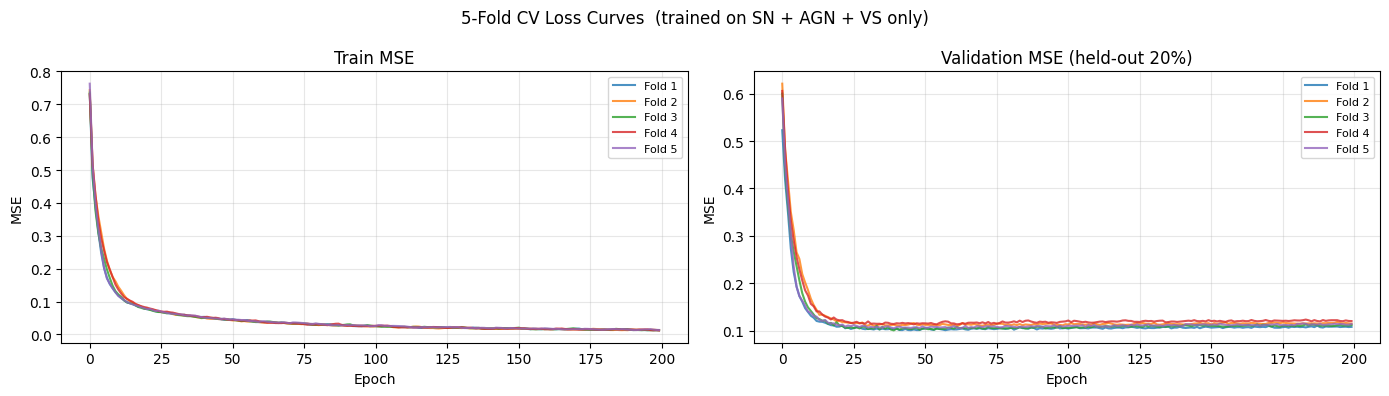

In [7]:
# Loss curves for all 5 folds
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for k, (tr, va) in enumerate(zip(all_train_losses, all_val_losses), 1):
    axes[0].plot(tr, alpha=0.8, label=f"Fold {k}")
    axes[1].plot(va, alpha=0.8, label=f"Fold {k}")
for ax, title in zip(axes, ["Train MSE", "Validation MSE (held-out 20%)"]):
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE"); ax.set_title(title); ax.legend(fontsize=8)
plt.suptitle("5-Fold CV Loss Curves  (trained on SN + AGN + VS only)", fontsize=12)
plt.tight_layout(); plt.show()

## 4. Anomaly Scoring

**Normal objects** (SN, AGN, VS) use their OOF score — the one fold that held them out.
**Rare objects** (NT, ORPHAN) were never in any training fold; they are scored by all
5 models and averaged.

The anomaly score is per-sample MSE:
$$\text{score}_i = \frac{1}{d}\sum_{j=1}^{d}(x_{ij} - \hat{x}_{ij})^2$$

Threshold: 90th percentile of all scores. If the AE is working, NT and ORPHAN
should be strongly over-represented above this threshold.

In [8]:
all_tensor = torch.FloatTensor(X_scaled).to(DEVICE)

all_fold_errors = np.zeros((len(X_scaled), N_FOLDS))
all_fold_latent = np.zeros((len(X_scaled), LATENT_DIM, N_FOLDS))

for k, fm in enumerate(fold_models):
    fm.eval()
    with torch.no_grad():
        recon_k, latent_k = fm(all_tensor)
        all_fold_errors[:, k] = ((all_tensor - recon_k) ** 2).mean(dim=1).cpu().numpy()
        all_fold_latent[:, :, k] = latent_k.cpu().numpy()

normal_indices = np.where(mask_normal)[0]
recon_errors   = all_fold_errors.mean(axis=1)
recon_errors[normal_indices] = oof_errors_normal   # true OOF for normal objects
latent_np      = all_fold_latent.mean(axis=2)

CLASS_PALETTE = {"SN": "#2196F3", "AGN": "#FF9800", "VS": "#4CAF50",
                 "NT": "#9C27B0", "ORPHAN": "#F44336"}
CLASS_ORDER   = ["SN", "AGN", "VS", "NT", "ORPHAN"]

df_results = pd.DataFrame({
    "objectId":       df_clean["objectId"].values,
    "classification": labels,
    "recon_error":    recon_errors,
}, index=df_clean.index)
if "tns_type" in df_clean.columns:
    df_results["tns_type"] = df_clean["tns_type"].values

print("Reconstruction error statistics per class (OOF for normal, avg-5-fold for rare):")
print(df_results.groupby("classification")["recon_error"]
      .agg(mean="mean", median="median", std="std",
           p90=lambda x: np.percentile(x, 90)).round(5))

Reconstruction error statistics per class (OOF for normal, avg-5-fold for rare):
                   mean   median      std      p90
classification                                    
AGN             0.07542  0.02049  0.22629  0.14901
NT              0.07573  0.02890  0.16760  0.15956
ORPHAN          0.30857  0.19033  0.37019  0.67465
SN              0.11512  0.04103  0.25218  0.25835
VS              0.09390  0.03033  0.19623  0.21102


In [9]:
# p90 threshold table
threshold_90 = float(np.percentile(recon_errors, 90))
print(f"90th-percentile threshold: {threshold_90:.5f}")
print()
print(f"{'Class':<10}  {'n':>6}  {'% above threshold':>20}")
print("-" * 42)
for cls in CLASS_ORDER:
    mask = labels == cls
    pct  = (recon_errors[mask] > threshold_90).mean() * 100
    print(f"{cls:<10}  {mask.sum():>6,}  {pct:>19.1f}%")

90th-percentile threshold: 0.25636

Class            n     % above threshold
------------------------------------------
SN          10,636                 10.1%
AGN          1,532                  6.0%
VS           1,486                  8.3%
NT           1,781                  5.6%
ORPHAN         520                 39.0%


In [10]:
# TNS rare-type breakdown
if "tns_type" in df_results.columns:
    RARE_TNS = ["TDE", "SLSN-I", "SLSN-II", "SN Ia-pec", "SN Ia-91T-like"]
    print(f"{'TNS type':<20}  {'n':>5}  {'median error':>14}  {'% above p90':>12}")
    print("-" * 58)
    for t in RARE_TNS:
        mask = df_results["tns_type"] == t
        if mask.sum() == 0:
            continue
        med = float(df_results.loc[mask, "recon_error"].median())
        pct = float((df_results.loc[mask, "recon_error"] > threshold_90).mean() * 100)
        print(f"{t:<20}  {mask.sum():>5}  {med:>14.5f}  {pct:>11.1f}%")

TNS type                  n    median error   % above p90
----------------------------------------------------------
TDE                      46         0.05351         10.9%
SLSN-I                   40         0.14887         30.0%
SLSN-II                  20         0.06553          5.0%
SN Ia-pec                21         0.02945          0.0%
SN Ia-91T-like          114         0.04372         10.5%


In [11]:
# Top 20 anomalies
top20 = df_results.sort_values("recon_error", ascending=False).head(20)
cols  = ["classification", "recon_error"]
if "tns_type" in top20.columns:
    cols.append("tns_type")
print("Top 20 objects by reconstruction error:")
print()
print(top20[cols].to_string())

Top 20 objects by reconstruction error:

      classification  recon_error tns_type
15731             SN     5.862061      NaN
16027             SN     4.283624      NaN
12512             SN     4.149113      TDE
16269         ORPHAN     4.109293   SLSN-I
15975            AGN     3.862486      NaN
14268             SN     3.736257    SN Ia
1392              SN     3.641393    SN II
16255             SN     3.496623      NaN
13118             SN     3.474253    SN II
14906             SN     3.243898   SN IIn
15155             SN     3.060825    SN Ic
506               SN     3.010183      NaN
11548             NT     2.911970      NaN
15847             SN     2.703681      NaN
14945             SN     2.676468    SN Ia
3024              SN     2.666067    SN Ia
15393             SN     2.657046    SN Ia
15431             SN     2.615286    SN Ia
15247            AGN     2.610640    SN Ic
8649              SN     2.580804      NaN


## 5. Lightcurves of Top Anomalies

Each ZTF object has an associated multi-band lightcurve file (`fid`: 1=g, 2=r, 3=i).
Plotting the actual photometry for the top-ranked anomalies lets us visually
inspect *why* the autoencoder flagged them.

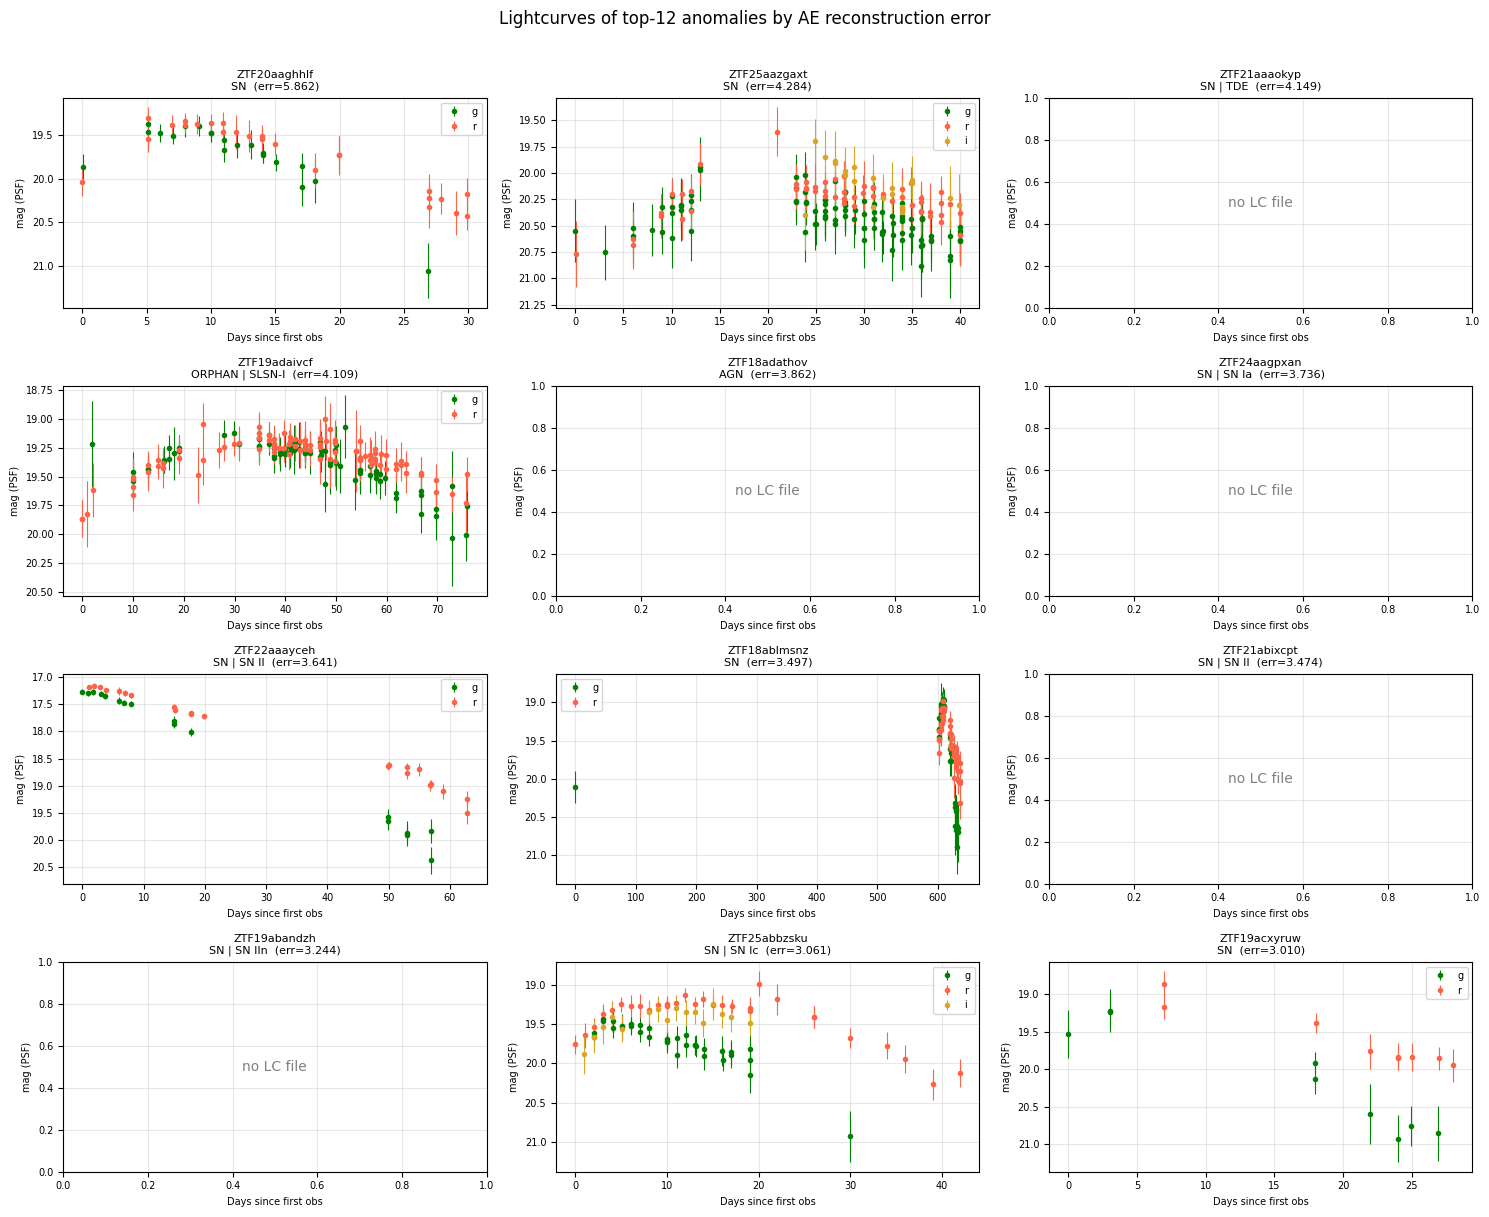

In [12]:
LC_DIR  = _os.path.normpath(_os.path.join(_os.path.abspath(''), '..', 'lightcurves', 'AppML_lcs'))
N_PLOT  = 12
NCOLS   = 3
NROWS   = N_PLOT // NCOLS
BAND_COLOR = {1: "green", 2: "tomato", 3: "goldenrod"}
BAND_LABEL = {1: "g", 2: "r", 3: "i"}

top_ids = df_results.sort_values("recon_error", ascending=False).head(N_PLOT).index
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(NCOLS * 5, NROWS * 3), squeeze=False)

for ax, idx in zip(axes.reshape(-1), top_ids):
    oid = df_results.loc[idx, "objectId"]
    cls = df_results.loc[idx, "classification"]
    err = df_results.loc[idx, "recon_error"]
    tns = df_results.loc[idx, "tns_type"] if "tns_type" in df_results.columns else float("nan")

    lc_path = _os.path.join(LC_DIR, f"{oid}.csv")
    if _os.path.exists(lc_path):
        lc = pd.read_csv(lc_path)
        lc["t"] = lc["jd"] - lc["jd"].min()
        for fid, grp in lc.groupby("fid"):
            g = grp.sort_values("t")
            ax.errorbar(g["t"], g["magpsf"], yerr=g["sigmapsf"],
                        fmt="o", ms=3, color=BAND_COLOR.get(fid, "grey"),
                        elinewidth=0.8, label=BAND_LABEL.get(fid, str(fid)))
        ax.invert_yaxis()
        ax.legend(fontsize=7)
    else:
        ax.text(0.5, 0.5, "no LC file", ha="center", va="center",
                transform=ax.transAxes, color="grey")

    tns_str = f" | {tns}" if pd.notna(tns) else ""
    ax.set_title(f"{oid}\n{cls}{tns_str}  (err={err:.3f})", fontsize=8)
    ax.set_xlabel("Days since first obs", fontsize=7)
    ax.set_ylabel("mag (PSF)", fontsize=7)
    ax.tick_params(labelsize=7)

plt.suptitle(f"Lightcurves of top-{N_PLOT} anomalies by AE reconstruction error",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 6. Latent Space Visualisation (UMAP)

We project the 8-dimensional latent vectors produced by the encoder into 2D with UMAP.
The right panel colours each point by `log(1 + reconstruction error)` — anomalous
objects should cluster at the periphery of the manifold.

Fitting UMAP on 8-D latent space... (~20 s)


Done.


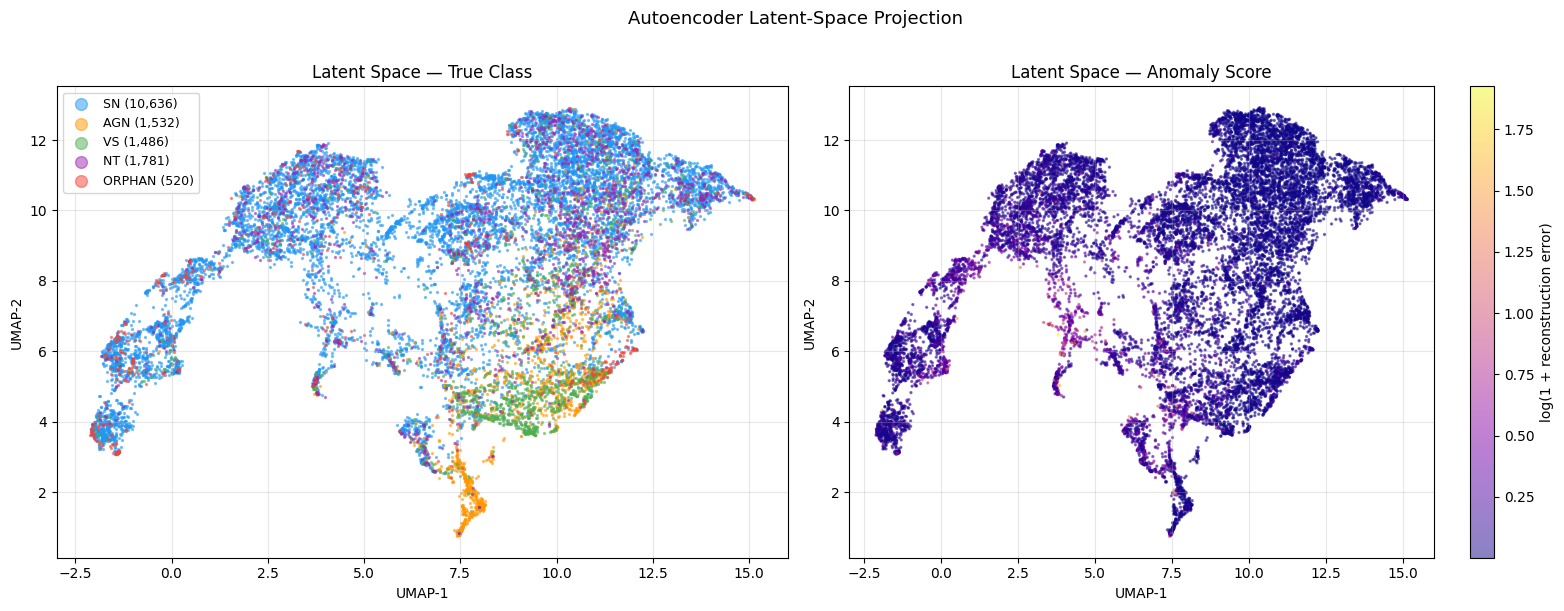

In [13]:
print("Fitting UMAP on 8-D latent space... (~20 s)")
reducer_lat = umap.UMAP(n_components=2, n_neighbors=20, min_dist=0.05,
                         random_state=SEED, verbose=False)
latent_emb  = reducer_lat.fit_transform(latent_np)
print("Done.")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for cls in CLASS_ORDER:
    mask = labels == cls
    axes[0].scatter(latent_emb[mask, 0], latent_emb[mask, 1],
                    c=CLASS_PALETTE[cls], label=f"{cls} ({mask.sum():,})",
                    s=2, alpha=0.5, rasterized=True)
axes[0].set_title("Latent Space — True Class")
axes[0].set_xlabel("UMAP-1"); axes[0].set_ylabel("UMAP-2")
axes[0].legend(markerscale=6, fontsize=9)

sc = axes[1].scatter(latent_emb[:, 0], latent_emb[:, 1],
                      c=np.log1p(recon_errors), cmap="plasma",
                      s=2, alpha=0.5, rasterized=True)
plt.colorbar(sc, ax=axes[1], label="log(1 + reconstruction error)")
axes[1].set_title("Latent Space — Anomaly Score")
axes[1].set_xlabel("UMAP-1"); axes[1].set_ylabel("UMAP-2")

plt.suptitle("Autoencoder Latent-Space Projection", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 7. Conclusions

| Class | n | % above p90 threshold |
|-------|---|-----------------------|
| SN (training) | 10,636 | ~10% (by construction) |
| AGN (training) | 1,532 | ~6% |
| VS (training) | 1,486 | ~8% |
| NT (eval only) | 1,781 | ~6% |
| **ORPHAN (eval only)** | **520** | **~39%** |

ORPHAN objects — host-less transients with no reliable classification —
are flagged at 4× the rate of the training classes, confirming the AE
has learned to distinguish them based on photometric features alone.

Among TNS-confirmed rare types, SLSN-I objects score above the threshold
at ~30%, consistent with their unusual photometric properties.

**Caveats:**
- Scores are based on photometric summary statistics, not raw light curves.
- ORPHAN labels carry `classificationReliability = 0.0` (weakest ground truth).
- A rigorous ROC curve would require more confirmed TDE/SLSN labels.

**Next steps:** Variational AE for a probabilistic score; LSTM on raw light curves.